In [1]:
import warnings
warnings.filterwarnings("ignore")

import shapely                 #needed to set geopandas geometry 
from shapely.wkt import loads  #needed to set geopandas geometry

import pandas as pd            #for DataFrame and analysis
import geopandas as gpd        #for mapping and spatial aggregation
import mapclassify as mp   #to view quantitative classification summaries

import numpy as np        #for working with arrays from mapclassify

import matplotlib.pyplot as plt  #use matplotlib to modify the plots (e.g. make them larger) 
import palettable.colorbrewer.sequential as pcs  #for colorBrewer palettes

In [2]:
df = pd.read_csv("UKCensus-21-11-London-21geog-data.csv")

gdf = gpd.GeoDataFrame(df)  #geopandas
gdf['geometry'] = gdf['geometry'].apply(lambda x: loads(x))  #from shapely
gdf = gdf.set_geometry('geometry')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4994 entries, 0 to 4993
Data columns (total 70 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   LSOA21CD          4994 non-null   object 
 1   LSOA21NM          4994 non-null   object 
 2   MSOA21CD          4994 non-null   object 
 3   MSOA21NM          4994 non-null   object 
 4   LAD22CD           4994 non-null   object 
 5   LAD22NM           4994 non-null   object 
 6   LSOA21KM2         4994 non-null   float64
 7   LSOAP21           4994 non-null   float64
 8   CHGIND            4994 non-null   object 
 9   geometry          4994 non-null   object 
 10  TotRes21          4994 non-null   int64  
 11  TotRes11_m21      4994 non-null   int64  
 12  TotHHolds21       4994 non-null   int64  
 13  TotHHolds11_m21   4994 non-null   int64  
 14  FemRes21          4994 non-null   int64  
 15  FemRes11_m21      4994 non-null   int64  
 16  MalRes21          4994 non-null   int64  


In [32]:
gdf['TotalAdults'] = gdf['AgeAdult21'] + gdf['AgeSenior21']

In [33]:
gdf['NoQualProp'] = gdf['QualNone21'] / gdf['TotalAdults']

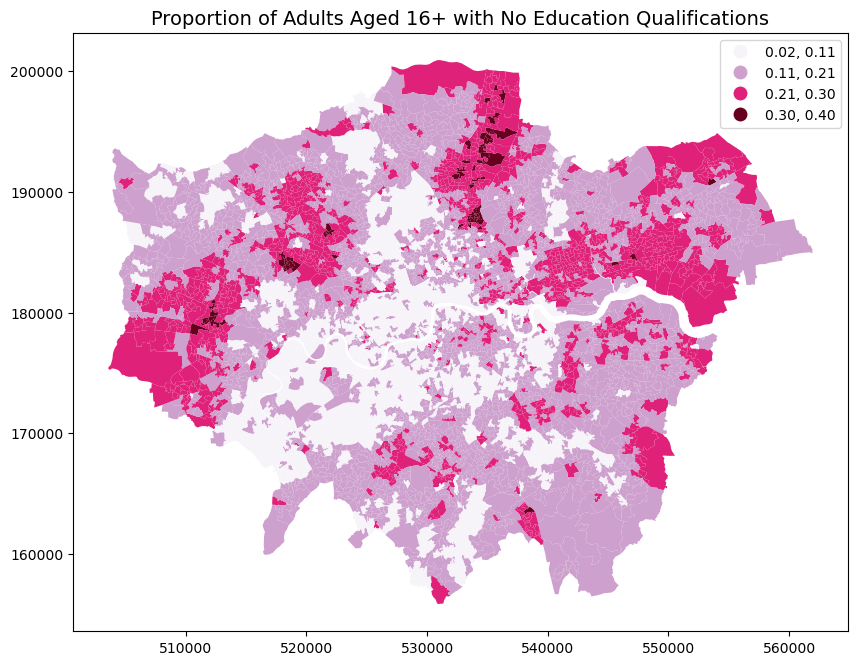

In [34]:
fig, ax1 = plt.subplots(1, figsize=(10, 10))
gdf.plot(column='NoQualProp',legend=True, cmap="PuRd", 
         scheme='equal_interval', k=4,
         ax=ax1)

plt.title('Proportion of Adults Aged 16+ with No Education Qualifications', size=14)

plt.savefig("/Users/kittymabel/Downloads/SDS 2/RESULTS/NoQual.png", dpi=300)


plt.show()

In [35]:
geom_data = pd.read_csv("UKCensus-21-11-London-21geog-data.csv")
iod_data = pd.read_csv("Copy of File_3_IoD2025_Supplementary_Indices_IDACI_and_IDAOPI.csv")

In [36]:
geom_data["LSOA21CD"] = geom_data["LSOA21CD"].str.strip()
iod_data["LSOA21CD"] = iod_data["LSOA21CD"].str.strip()

In [37]:
merged_df = geom_data.merge(
    iod_data,
    on="LSOA21CD",
    how="left"
)


In [38]:
merged_df.to_csv(
    "merged_lsoa_data.csv",
    index=False
)

In [39]:
iod_df = pd.read_csv("merged_lsoa_data.csv")

iod_gdf = gpd.GeoDataFrame(iod_df) 
iod_gdf['geometry'] = iod_gdf['geometry'].apply(lambda x: loads(x)) 
iod_gdf = iod_gdf.set_geometry('geometry')

In [40]:
print(iod_gdf.columns)

Index(['LSOA21CD', 'LSOA21NM', 'MSOA21CD', 'MSOA21NM', 'LAD22CD', 'LAD22NM',
       'LSOA21KM2', 'LSOAP21', 'CHGIND', 'geometry', 'TotRes21',
       'TotRes11_m21', 'TotHHolds21', 'TotHHolds11_m21', 'FemRes21',
       'FemRes11_m21', 'MalRes21', 'MalRes11_m21', 'Asian21', 'Asian11_m21',
       'Black21', 'Black11_m21', 'MixedE21', 'MixedE11_m21', 'White21',
       'White11_m21', 'OtherE21', 'OtherE11_m21', 'CarsZero21',
       'CarsZero11_m21', 'CarsOne21', 'CarsOne11_m21', 'CarsTwo21',
       'CarsTwo11_m21', 'CarsThrp21', 'CarsThrp11_m21', 'EconEm21',
       'EconEm11_m21', 'EconUn21', 'EconUn11_m21', 'EconSt21', 'EconSt11_m21',
       'EconRe21', 'EconRe11_m21', 'EconOt21', 'EconOt11_m21', 'AgeChild21',
       'AgeChild11_m21', 'AgeAdult21', 'AgeAdult11_m21', 'AgeSenior21',
       'AgeSenior11_m21', 'HealthVG21', 'HealthVG11_m21', 'HealthGood21',
       'HealthGood11_m21', 'HealthFair21', 'HealthFair11_m21', 'HealthBad21',
       'HealthBad11_m21', 'HealthVB21', 'HealthVB11_m21', 'Q

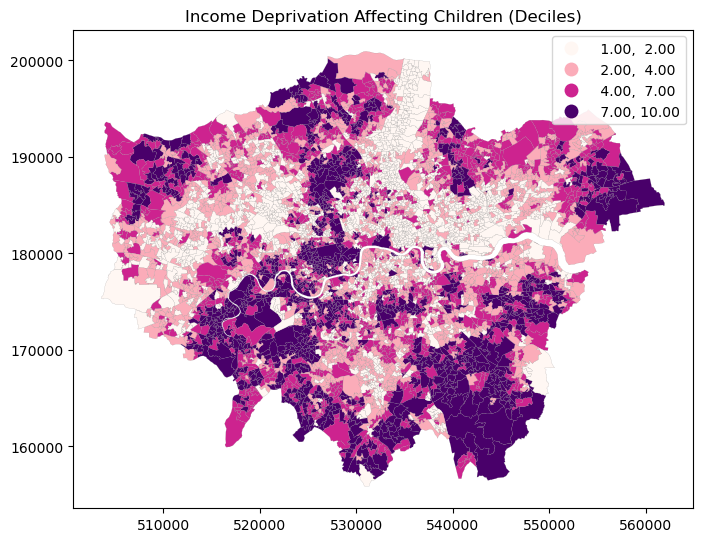

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(8, 10))

iod_gdf.plot(
    column='Income Deprivation Affecting Children Index (IDACI) Decile (where 1 is most deprived 10% of LSOAs)', 
    cmap="RdPu",
    legend=True,
    ax=ax,
    linewidth=0.1,
    edgecolor="grey",
    scheme="Quantiles",
    k=4
)

ax.set_title("Income Deprivation Affecting Children (Deciles)")
ax.axis("on")

plt.savefig("/Users/kittymabel/Downloads/SDS 2/RESULTS/DeprivationDecile.png", dpi=300)

plt.show()

In [42]:
gdf = gdf.merge(
    iod_gdf[["LSOA21CD", "Income Deprivation Affecting Children Index (IDACI) Decile (where 1 is most deprived 10% of LSOAs)"]],
    on="LSOA21CD",
    how="left"
)

In [43]:
import libpysal as lps
from esda.moran import Moran

In [44]:
gdf['NoQualProp'] = gdf['QualNone21'] / gdf['TotRes21']


In [45]:
w = lps.weights.Queen.from_dataframe(gdf)
w.transform = "r"

In [46]:
y = gdf["NoQualProp"].values

moran_edu = Moran(y, w)

In [47]:
print("Moran's I (No qualifications proportion):", moran_edu.I)
print("p-value:", moran_edu.p_sim)


Moran's I (No qualifications proportion): 0.650592137198871
p-value: 0.001


In [48]:
print(gdf.columns)

Index(['LSOA21CD', 'LSOA21NM', 'MSOA21CD', 'MSOA21NM', 'LAD22CD', 'LAD22NM',
       'LSOA21KM2', 'LSOAP21', 'CHGIND', 'geometry', 'TotRes21',
       'TotRes11_m21', 'TotHHolds21', 'TotHHolds11_m21', 'FemRes21',
       'FemRes11_m21', 'MalRes21', 'MalRes11_m21', 'Asian21', 'Asian11_m21',
       'Black21', 'Black11_m21', 'MixedE21', 'MixedE11_m21', 'White21',
       'White11_m21', 'OtherE21', 'OtherE11_m21', 'CarsZero21',
       'CarsZero11_m21', 'CarsOne21', 'CarsOne11_m21', 'CarsTwo21',
       'CarsTwo11_m21', 'CarsThrp21', 'CarsThrp11_m21', 'EconEm21',
       'EconEm11_m21', 'EconUn21', 'EconUn11_m21', 'EconSt21', 'EconSt11_m21',
       'EconRe21', 'EconRe11_m21', 'EconOt21', 'EconOt11_m21', 'AgeChild21',
       'AgeChild11_m21', 'AgeAdult21', 'AgeAdult11_m21', 'AgeSenior21',
       'AgeSenior11_m21', 'HealthVG21', 'HealthVG11_m21', 'HealthGood21',
       'HealthGood11_m21', 'HealthFair21', 'HealthFair11_m21', 'HealthBad21',
       'HealthBad11_m21', 'HealthVB21', 'HealthVB11_m21', 'Q

In [52]:
gdf = gdf[gdf["Income Deprivation Affecting Children Index (IDACI) Decile (where 1 is most deprived 10% of LSOAs)_x"].notnull()]
gdf = gdf.reset_index(drop=True)

In [53]:
w1 = lps.weights.Queen.from_dataframe(gdf)

w1.transform = "r"

In [54]:
y1 = gdf["Income Deprivation Affecting Children Index (IDACI) Decile (where 1 is most deprived 10% of LSOAs)_x"].values

moran_idaci = Moran(y1, w1)

print("Moran's I (IDACI decile):", moran_idaci.I)
print("p-value:", moran_idaci.p_sim)

Moran's I (IDACI decile): 0.6177709143725136
p-value: 0.001


In [55]:
import statsmodels.formula.api as smf 
import statsmodels.api as sm

In [70]:
gdf = gdf.rename(columns={
    "Income Deprivation Affecting Children Index (IDACI) Decile (where 1 is most deprived 10% of LSOAs)_x": "IDACI_score"
})

In [71]:
print(gdf.columns.tolist())

['LSOA21CD', 'LSOA21NM', 'MSOA21CD', 'MSOA21NM', 'LAD22CD', 'LAD22NM', 'LSOA21KM2', 'LSOAP21', 'CHGIND', 'geometry', 'TotRes21', 'TotRes11_m21', 'TotHHolds21', 'TotHHolds11_m21', 'FemRes21', 'FemRes11_m21', 'MalRes21', 'MalRes11_m21', 'Asian21', 'Asian11_m21', 'Black21', 'Black11_m21', 'MixedE21', 'MixedE11_m21', 'White21', 'White11_m21', 'OtherE21', 'OtherE11_m21', 'CarsZero21', 'CarsZero11_m21', 'CarsOne21', 'CarsOne11_m21', 'CarsTwo21', 'CarsTwo11_m21', 'CarsThrp21', 'CarsThrp11_m21', 'EconEm21', 'EconEm11_m21', 'EconUn21', 'EconUn11_m21', 'EconSt21', 'EconSt11_m21', 'EconRe21', 'EconRe11_m21', 'EconOt21', 'EconOt11_m21', 'AgeChild21', 'AgeChild11_m21', 'AgeAdult21', 'AgeAdult11_m21', 'AgeSenior21', 'AgeSenior11_m21', 'HealthVG21', 'HealthVG11_m21', 'HealthGood21', 'HealthGood11_m21', 'HealthFair21', 'HealthFair11_m21', 'HealthBad21', 'HealthBad11_m21', 'HealthVB21', 'HealthVB11_m21', 'QualNone21', 'QualNone11_m21', 'QualSch21', 'QualSch11_m21', 'QualUni21', 'QualUni11_m21', 'QualOt

In [91]:
y = gdf["IDACI_score"]

X = gdf[["NoQualProp"]] 

X = sm.add_constant(X)

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

with open("/Users/kittymabel/Downloads/SDS 2/RESULTS/OLS1.txt", "w") as f:
    f.write(lag_model.summary)



                            OLS Regression Results                            
Dep. Variable:            IDACI_score   R-squared:                       0.412
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     3501.
Date:                Thu, 08 Jan 2026   Prob (F-statistic):               0.00
Time:                        18:18:13   Log-Likelihood:                -11004.
No. Observations:                4994   AIC:                         2.201e+04
Df Residuals:                    4992   BIC:                         2.202e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.4694      0.088    107.849      0.0

In [92]:
gdf["ols_residuals"] = ols_model.resid

In [93]:
from libpysal.weights import Queen
from esda.moran import Moran

In [94]:
w = Queen.from_dataframe(gdf)

w.transform = "r"


In [95]:
moran_resid = Moran(gdf["ols_residuals"], w)

print("Moran's I (OLS residuals):", moran_resid.I)
print("p-value:", moran_resid.p_sim)


Moran's I (OLS residuals): 0.5397104098935508
p-value: 0.001


In [96]:
from spreg import ML_Lag

In [97]:
y = gdf["IDACI_score"].values.reshape(-1, 1)

X = gdf[["NoQualProp"]].values

In [98]:
w = Queen.from_dataframe(gdf)
w.transform = "r"

In [99]:
lag_model = ML_Lag(
    y=y,
    x=X,
    w=w,
    name_y="IDACI_score",
    name_x=["NoQualProp"]
)

with open("/Users/kittymabel/Downloads/SDS 2/RESULTS/spatial_lag_results.txt", "w") as f:
    f.write(lag_model.summary)


print(lag_model.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  : IDACI_score                Number of Observations:        4994
Mean dependent var  :      4.6093                Number of Variables   :           3
S.D. dependent var  :      2.8584                Degrees of Freedom    :        4991
Pseudo R-squared    :      0.6601
Spatial Pseudo R-squared:  0.3825
Log likelihood      :  -9865.4780
Sigma-square ML     :      2.7940                Akaike info criterion :   19736.956
S.E of regression   :      1.6715                Schwarz criterion     :   19756.504

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
---------------------------------------------------------------